## Notebook 04: Comparativa de Modelos ML
## Entrenamiento y evaluación de modelos de clasificación para predecir attrition.

In [1]:
# --- Imports ML ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score)
from imblearn.over_sampling import SMOTE

# Carga del dataset limpio
ibm_clean = pd.read_csv('../data/processed/ibm_hr_clean.csv')
print(f'Dataset cargado: {ibm_clean.shape}')

Dataset cargado: (1470, 31)


In [6]:
# --- Preparación de datos para modelado ---

# One-hot encoding para variables categóricas
ibm_encoded = pd.get_dummies(ibm_clean, drop_first=True)
X = ibm_encoded.drop(columns=['Attrition'])
y = ibm_encoded['Attrition']

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(f'Train: {X_train.shape[0]} filas')
print(f'Test: {X_test.shape[0]} filas')
print(f'Balance train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Balance test: {y_test.value_counts(normalize=True).round(3).to_dict()}')

Train: 1029 filas
Test: 441 filas
Balance train: {0: 0.829, 1: 0.171}
Balance test: {0: 0.862, 1: 0.138}


Nota: Probamos con 70/30 y con 80/20, la diferencia es muy pequeña casi inexistente.

Las proporciones no son iguales entre train y test, para que quede igual encontramos el parámetro stratify que mantiene la misma proporción en ambos sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f'Balance train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Balance test: {y_test.value_counts(normalize=True).round(3).to_dict()}')

Balance train: {0: 0.839, 1: 0.161}
Balance test: {0: 0.839, 1: 0.161}


In [5]:
# --- SMOTE y escalado ---

# SMOTE: Con esto creamos empleados sintéticos para equilibrar las clases, que en el EDA nos dimos cuenta que estaba desbalanceado.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Antes de SMOTE: {len(X_train)} filas')
print(f'Después de SMOTE: {len(X_train_smote)} filas')
print(f'Balance: {pd.Series(y_train_smote).value_counts().to_dict()}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

Antes de SMOTE: 1029 filas
Después de SMOTE: 1726 filas
Balance: {0: 863, 1: 863}


In [8]:
# --- Logistic Regression ---

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_smote)

# Predecir
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== LOGISTIC REGRESSION ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'F1: {f1_score(y_test, y_pred_lr):.4f}')
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

=== LOGISTIC REGRESSION ===
Accuracy: 0.8503
Recall: 0.4507
Precision: 0.5424
F1: 0.4923
AUC-ROC: 0.7592

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       370
           1       0.54      0.45      0.49        71

    accuracy                           0.85       441
   macro avg       0.72      0.69      0.70       441
weighted avg       0.84      0.85      0.84       441



In [11]:
# --- Logistic Regression ---

lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train_scaled, y_train_smote)

# Predecir
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== LOGISTIC REGRESSION ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'F1: {f1_score(y_test, y_pred_lr):.4f}')
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

=== LOGISTIC REGRESSION ===
Accuracy: 0.8503
Recall: 0.4507
Precision: 0.5424
F1: 0.4923
AUC-ROC: 0.7592

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       370
           1       0.54      0.45      0.49        71

    accuracy                           0.85       441
   macro avg       0.72      0.69      0.70       441
weighted avg       0.84      0.85      0.84       441



Los resultados son iguales con distintas iteraciones. Al parecer el modelo deja de mejorar antes de las 200 iteraciones, por lo que no es necesario aumentar el número. Nos quedamos con max_iter=200.

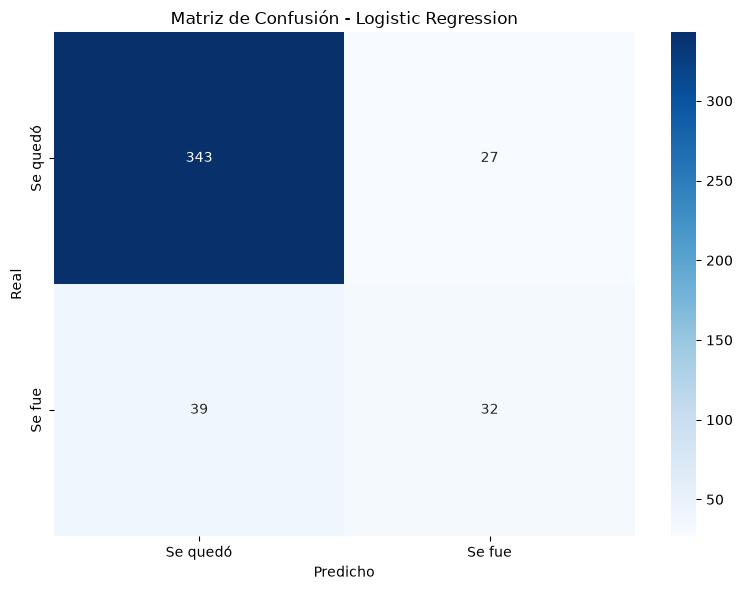

In [14]:
# --- Matriz de confusión LR ---

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Se quedó', 'Se fue'],
            yticklabels=['Se quedó', 'Se fue'])
ax.set_title('Matriz de Confusión - Logistic Regression')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig('../reports/figures/cm_logistic_regression.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# --- Random Forest ---

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=50,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

# Predecir
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'F1: {f1_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.8209
Recall: 0.2113
Precision: 0.3947
F1: 0.2752
AUC-ROC: 0.7541

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       370
           1       0.39      0.21      0.28        71

    accuracy                           0.82       441
   macro avg       0.63      0.57      0.59       441
weighted avg       0.79      0.82      0.80       441



In [18]:
# --- Random Forest ---

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

# Predecir
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'F1: {f1_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.8254
Recall: 0.2394
Precision: 0.4250
F1: 0.3063
AUC-ROC: 0.7623

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       370
           1       0.42      0.24      0.31        71

    accuracy                           0.83       441
   macro avg       0.65      0.59      0.60       441
weighted avg       0.79      0.83      0.80       441



In [19]:
# --- Random Forest ---

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

# Predecir
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'F1: {f1_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.8277
Recall: 0.2535
Precision: 0.4390
F1: 0.3214
AUC-ROC: 0.7583

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       370
           1       0.44      0.25      0.32        71

    accuracy                           0.83       441
   macro avg       0.65      0.60      0.61       441
weighted avg       0.80      0.83      0.81       441



Probamos 3 configuraciones y con max_depth=10 obtuvimos el mejor Recall (0.25) y F1 (0.32), por lo que vemos que un árbol menos profundo generaliza mejor y nos quedamos con ese.

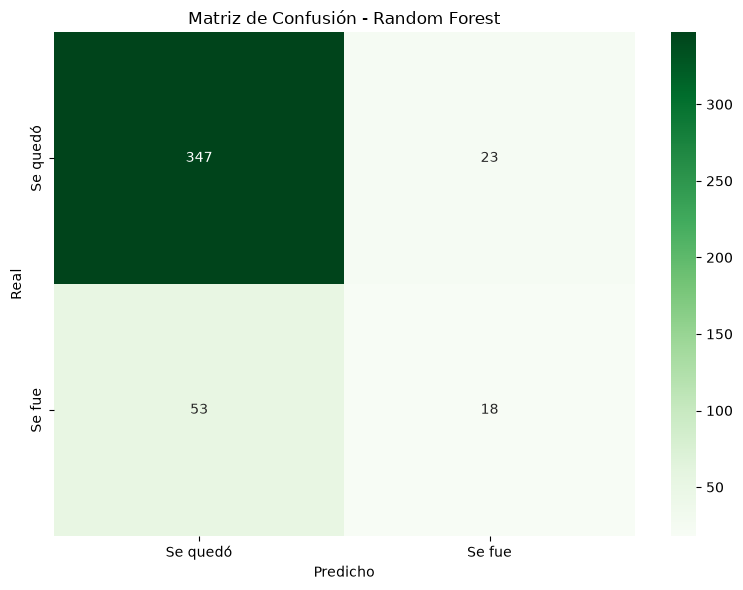

In [20]:
# --- Matriz de confusión RF ---

fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Se quedó', 'Se fue'],
            yticklabels=['Se quedó', 'Se fue'])
ax.set_title('Matriz de Confusión - Random Forest')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig('../reports/figures/cm_random_forest.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# --- Comparativa LR vs RF ---

comparativa = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr),
               recall_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_rf)],
    'F1': [f1_score(y_test, y_pred_lr),
           f1_score(y_test, y_pred_rf)],
    'AUC-ROC': [roc_auc_score(y_test, y_prob_lr),
                roc_auc_score(y_test, y_prob_rf)],
}).round(4)

print('=== COMPARATIVA DE MODELOS ===')
print(comparativa.to_string(index=False))

# Guardar tabla
comparativa.to_csv('../reports/tables/comparativa_modelos.csv', index=False)
print('\nTabla guardada')

=== COMPARATIVA DE MODELOS ===
             Modelo  Accuracy  Recall  Precision     F1  AUC-ROC
Logistic Regression    0.8503  0.4507     0.5424 0.4923   0.7592
      Random Forest    0.8277  0.2535     0.4390 0.3214   0.7583

Tabla guardada


## Observaciones iniciales de ambos modelos (LR vs RF)

- Logistic Regression supera a Random Forest en Recall (0.45 vs 0.25) y en todas las métricas.
- Ninguno de los dos detecta bien a los empleados que se van (Recall bajo en ambos).
- Pendiente: probar XGBoost, SVM y MLP para intentar mejorar el Recall.